In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.pyplot import MultipleLocator
import os
os.environ["PATH"] = "/opt/software-current/2023.06/x86_64/generic/software/texlive/20230313-GCC-12.3.0/bin/x86_64-linux:/Library/TeX/texbin:" + os.environ.get("PATH","")
from scipy.stats import gaussian_kde
from PIL import Image
import numpy as np

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    # ---------- LaTeX ----------
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # ---------- Font sizes ----------
    "font.size": 24,            # 全局默认字号
    "axes.labelsize": 24,       # 坐标轴标题
    "axes.titlesize": 24,       # 子图标题
    "xtick.labelsize": 24,      # x 轴刻度
    "ytick.labelsize": 24,      # y 轴刻度
    "legend.fontsize": 24,      # 图例字号
    "legend.title_fontsize": 24,

    # ---------- Axes ----------
    "axes.linewidth": 1.2,      # 坐标轴边框线宽
    "axes.unicode_minus": False,

    # ---------- Lines ----------
    "lines.linewidth": 2.0,
    "lines.markersize": 8,

    # ---------- Ticks ----------
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    # ---------- Legend ----------
    "legend.frameon": False,    # 论文图通常不用边框
    "legend.handlelength": 1.8,
    "legend.handletextpad": 0.4,
    "legend.borderpad": 0.3,
    "legend.labelspacing": 0.3,

    # ---------- Figure ----------
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    # ---------- PDF/PS ----------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

ModuleNotFoundError: No module named 'numpy._core'

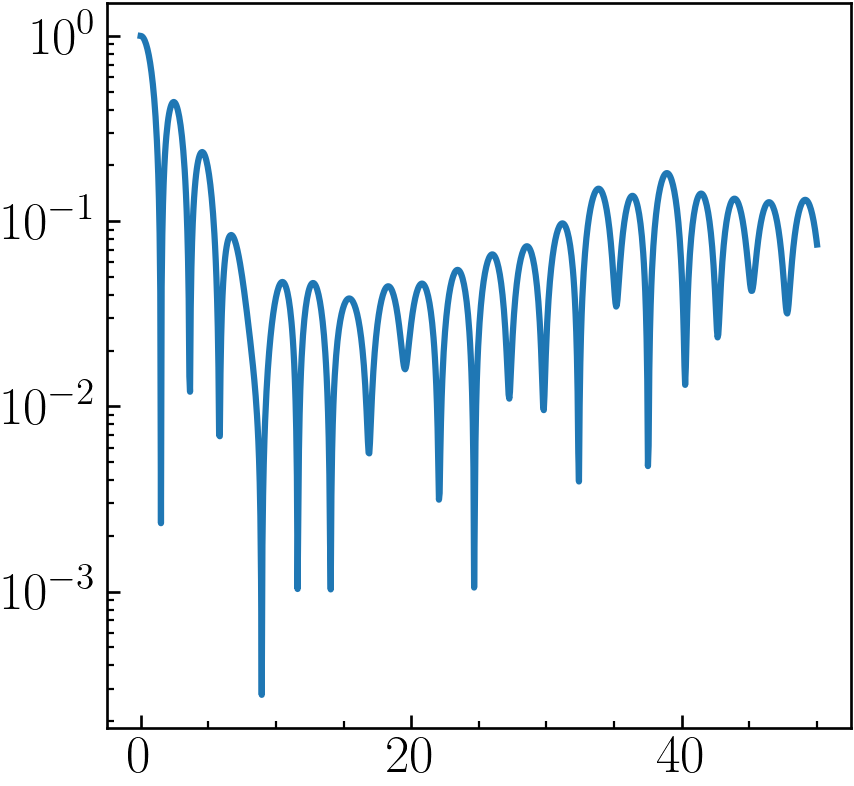

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def mode_amplitude(field_grid, mode):
    coeffs = np.fft.fft(field_grid) / field_grid.size
    return 2.0 * np.abs(coeffs[mode])

def load_E_mode(filepath):
    da = np.load(filepath, allow_pickle=True)
    times = da["times"]
    mode = int(da["config"].item()["mode"])
    E_mode_est = np.array([mode_amplitude(E, mode) for E in da["electric_est"]])
    return times, np.maximum(E_mode_est, 1e-16)

fig,ax=plt.subplots(figsize=(6, 6), dpi=160)

# True
data = np.load("./simulation/data/mv_sim_seed0.npz")
plt.semilogy(
    data["times"],
    np.maximum(data["E_mode"], 1e-16),
    label="True",
    linewidth=2.8
)

# Biased prediction
times, E_mode_est = load_E_mode("./assimilation/data_lambda_0/phase_da_kdenudge_1d1v_seed0.npz")
plt.semilogy(
    times,
    E_mode_est,
    label="Biased Prediction",
    linewidth=2.4,
    linestyle="--"
)

# lambda = 1e-5
times, E_mode_est = load_E_mode("./assimilation/data_lambda_1e_3/phase_da_kdenudge_1d1v_seed0.npz")
plt.semilogy(
    times,
    E_mode_est,
    label=r"$\lambda=10^{-5}$",
    linewidth=2.4,
    linestyle="-."
)

# lambda = 1e-4
times, E_mode_est = load_E_mode("./assimilation/data_lambda_1e_4/phase_da_kdenudge_1d1v_seed0.npz")
plt.semilogy(
    times,
    E_mode_est,
    label=r"$\lambda=10^{-4}$",
    linewidth=2.4,
    linestyle=":"
)

plt.ylim(1e-3, 1)
plt.xlabel("t")
plt.ylabel(r"$|E_k(t)|$")

fig.legend(  ncol=2,
           loc='upper center',
           bbox_to_anchor=(0.5, 1.05))
plt.savefig("landua_damping")